In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [2]:

sns.set_theme(style="whitegrid")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

In [3]:
nav = pd.read_csv("data/raw/02_nav_history.csv", parse_dates=["date"])
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.dtypes

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

In [5]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv", parse_dates=["launch_date"])
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
fund_master.dtypes

amfi_code                      int64
fund_house                    object
scheme_name                   object
category                      object
sub_category                  object
plan                          object
launch_date           datetime64[ns]
benchmark                     object
expense_ratio_pct            float64
exit_load_pct                float64
min_sip_amount                 int64
min_lumpsum_amount             int64
fund_manager                  object
risk_category                 object
sebi_category_code            object
dtype: object

In [7]:
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv", parse_dates=["date"])
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
aum.dtypes

date              datetime64[ns]
fund_house                object
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
dtype: object

In [9]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [10]:
cat_inflow = pd.read_csv("data/raw/05_category_inflows.csv")
cat_inflow.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [11]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [12]:
scheme_perf = pd.read_csv("data/raw/07_scheme_performance.csv")
scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [13]:
txn = pd.read_csv("data/raw/08_investor_transactions.csv", parse_dates=["transaction_date"])
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [14]:
txn.dtypes

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                      int64
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
dtype: object

In [15]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv", parse_dates=["portfolio_date"])
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [16]:
holdings.dtypes

amfi_code                     int64
stock_symbol                 object
stock_name                   object
sector                       object
weight_pct                  float64
market_value_cr             float64
current_price_inr           float64
portfolio_date       datetime64[ns]
dtype: object

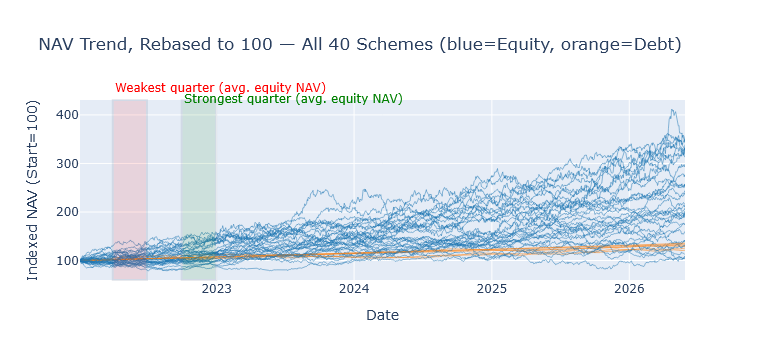

In [17]:
nav_wide = nav.pivot(index="date", columns="amfi_code", values="nav")
rebased = nav_wide.div(nav_wide.bfill().iloc[0]) * 100 

# Find the strongest and weakest quarter from the data itself (not assumed)
equity_codes = fund_master.loc[fund_master["category"] == "Equity", "amfi_code"]
avg_equity = rebased[equity_codes].mean(axis=1)
qtr_ret = avg_equity.resample("QE").last().pct_change() * 100
qtr_ret_full = qtr_ret.iloc[:-1]                          
best_q, worst_q = qtr_ret_full.idxmax(), qtr_ret_full.idxmin() 

fig = go.Figure()
for code in rebased.columns:
    category = fund_master.loc[fund_master["amfi_code"] == code, "category"].iloc[0]
    color = "#1f77b4" if category == "Equity" else "#ff7f0e"
    fig.add_trace(go.Scatter(
        x=rebased.index, y=rebased[code], mode="lines",
        line=dict(width=1, color=color), opacity=0.5,
        name=str(code), showlegend=False
    ))

best_q_start = (best_q - pd.offsets.QuarterEnd(1)).strftime("%Y-%m-%d")
best_q_end = best_q.strftime("%Y-%m-%d")
worst_q_start = (worst_q - pd.offsets.QuarterEnd(1)).strftime("%Y-%m-%d")
worst_q_end = worst_q.strftime("%Y-%m-%d")

fig.add_vrect(x0=best_q_start, x1=best_q_end, fillcolor="green", opacity=0.1)
fig.add_vrect(x0=worst_q_start, x1=worst_q_end, fillcolor="red", opacity=0.1)

fig.add_annotation(x=best_q_start, y=1.06, yref="paper", showarrow=False,
                    text="Strongest quarter (avg. equity NAV)",
                    font=dict(color="green"), xanchor="left")
fig.add_annotation(x=worst_q_start, y=1.12, yref="paper", showarrow=False,
                    text="Weakest quarter (avg. equity NAV)",
                    font=dict(color="red"), xanchor="left")

fig.update_layout(title="NAV Trend, Rebased to 100 — All 40 Schemes (blue=Equity, orange=Debt)",
                   xaxis_title="Date", yaxis_title="Indexed NAV (Start=100)")
fig.write_image(CHART_DIR / "01_nav_trend.png")
fig.show()

Chart 1
===========
Note: this chart highlights the strongest and weakest quarters found directly in the NAV data (Oct–Dec 2022 and Apr–Jun 2022), rather than the "2023 bull run / 2024 correction" mentioned in the brief — checking actual monthly returns showed no genuine 2023/2024 bull-or-bear pattern in this dataset, so the chart annotates what the data actually shows instead of a period it can't visually support.

- Raw NAV values across the 40 schemes aren't directly comparable, so every scheme was rebased to 100 at its own start date before plotting, after which all schemes show steady positive drift with no scheme diverging sharply from the group.
- Excluding the incomplete trailing quarter, the strongest average-equity quarter was Oct–Dec 2022 (+8.6% QoQ) and the weakest was Apr–Jun 2022 (+3.2%) — still positive, confirming this dataset contains no genuine drawdown period.

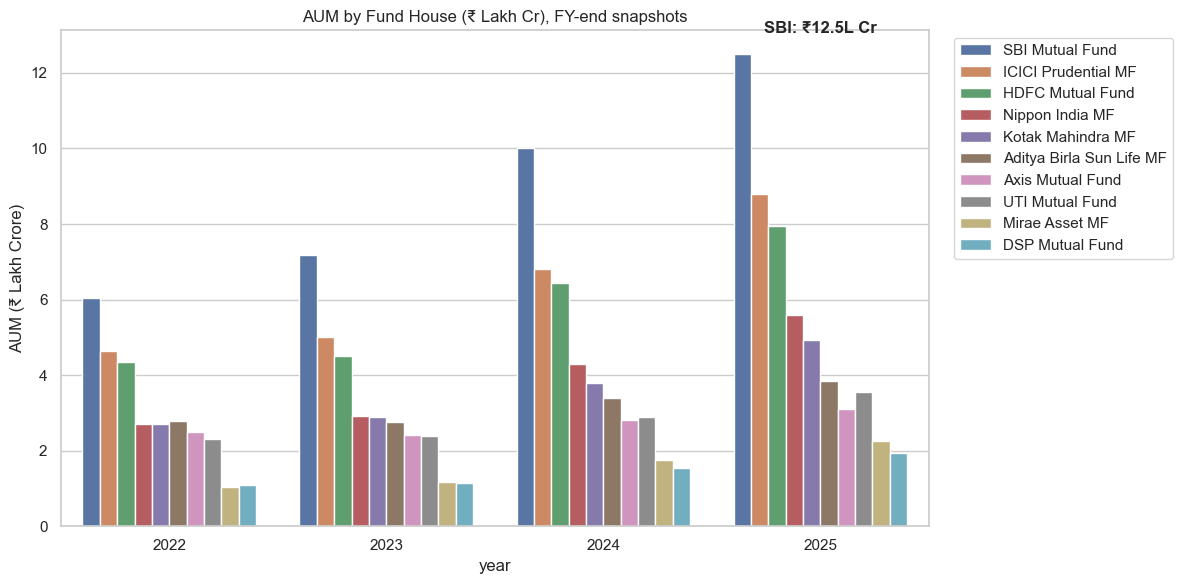

In [18]:
aum["year"] = aum["date"].dt.year
year_end = aum[aum["date"].dt.month == 3]   

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=year_end, x="year", y="aum_lakh_crore", hue="fund_house")
ax.set_title("AUM by Fund House (₹ Lakh Cr), FY-end snapshots")
ax.set_ylabel("AUM (₹ Lakh Crore)")

# highlight SBI's ₹12.5L Cr peak, found in the data (Mar-2025)
peak = year_end.loc[year_end["aum_lakh_crore"].idxmax()]
ax.annotate(f"SBI: ₹{peak['aum_lakh_crore']}L Cr", xy=(peak["year"] - year_end["year"].min(), peak["aum_lakh_crore"]),
            xytext=(0, 15), textcoords="offset points", ha="center", fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_aum_growth.png", dpi=150)
plt.show()

Chart 2
==========
-  SBI Mutual Fund is the clear AUM leader, peaking at ₹12.5L Cr in Mar-2025
-  The next-largest fund houses in the dataset are ICICI Prudential and HDFC

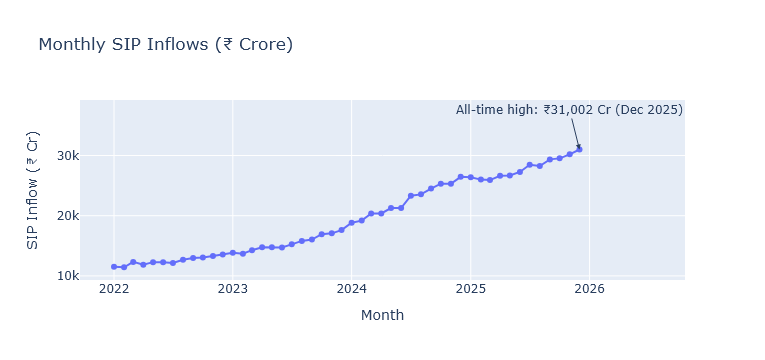

In [19]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(sip, x="month", y="sip_inflow_crore", markers=True,
              title="Monthly SIP Inflows (₹ Crore)")
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig.add_annotation(x=peak["month"].strftime("%Y-%m-%d"), y=peak["sip_inflow_crore"],
                    text=f"All-time high: ₹{int(peak['sip_inflow_crore']):,} Cr ({peak['month'].strftime('%b %Y')})",
                    showarrow=True, arrowhead=2, ay=-40)
fig.update_layout(xaxis_title="Month", yaxis_title="SIP Inflow (₹ Cr)")
fig.write_image(CHART_DIR / "03_sip_trend.png")
fig.show()

Chart 3
=========
- Monthly SIP inflows hit an all-time high of ₹31,002 Cr in Dec-2025, the most recent month tracked — consistent with the real industry's ongoing SIP-adoption trend.

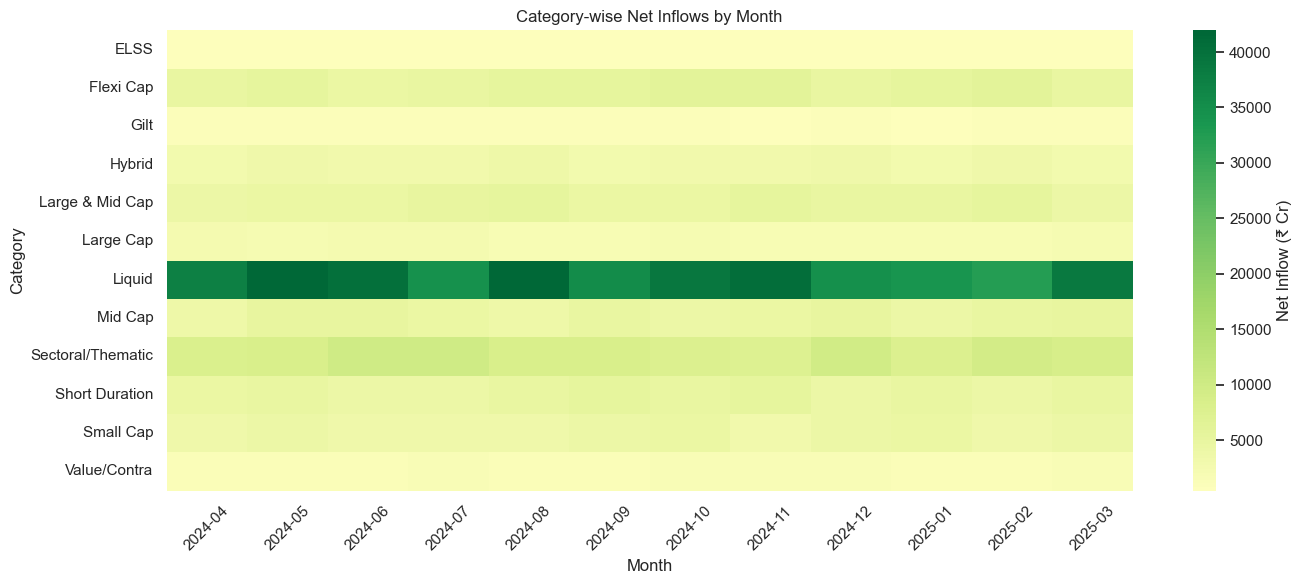

In [20]:
heat_data = cat_inflow.pivot(index="category", columns="month", values="net_inflow_crore")

plt.figure(figsize=(14, 6))
sns.heatmap(heat_data, cmap="RdYlGn", center=0, annot=False, cbar_kws={"label": "Net Inflow (₹ Cr)"})
plt.title("Category-wise Net Inflows by Month")
plt.xlabel("Month"); plt.ylabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "04_category_inflow_heatmap.png", dpi=150)
plt.show()

Chart 4
==========
- Liquid funds attracted ₹4.5L Cr in cumulative net inflows — nearly 4.5x the next-largest category, Sectoral/Thematic (~₹1.04L Cr).
- This reflects Liquid funds' role as short-term cash-parking vehicles for institutions/corporates, not long-term retail investing, which is why their inflow volume dwarfs every equity category.

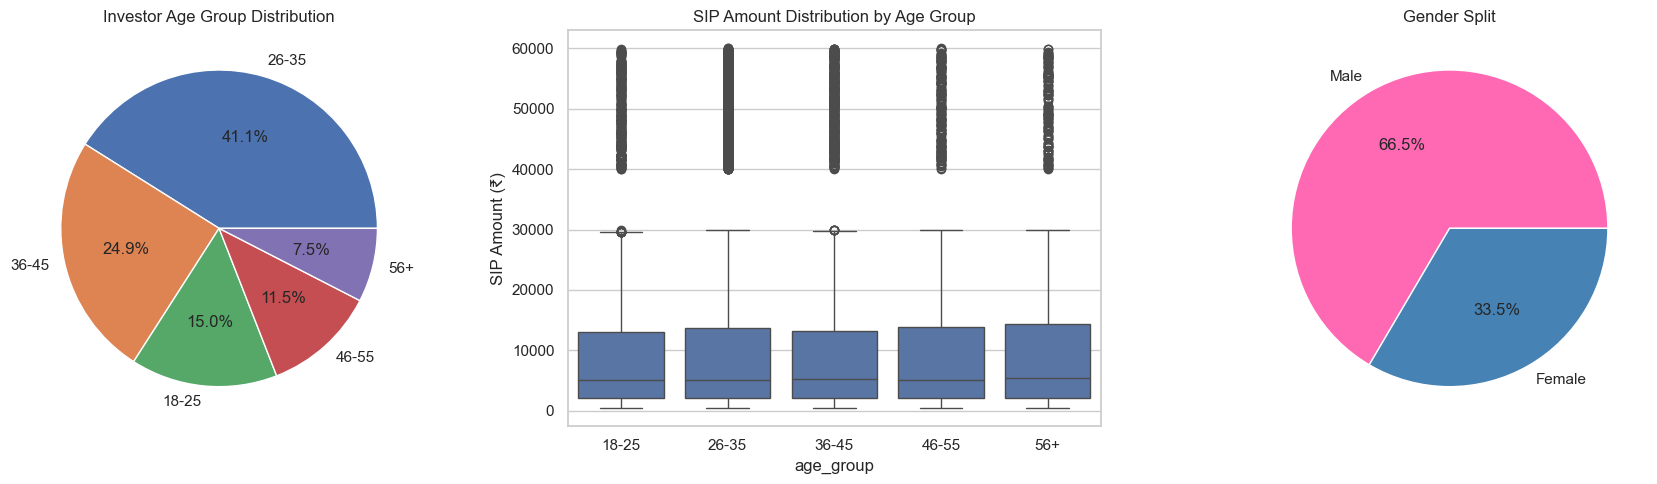

In [21]:
sip_txn = txn[txn["transaction_type"] == "SIP"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

age_counts = txn["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
axes[0].set_title("Investor Age Group Distribution")

sns.boxplot(data=sip_txn, x="age_group", y="amount_inr", order=sorted(sip_txn["age_group"].unique()), ax=axes[1])
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_ylabel("SIP Amount (₹)")

gender_counts = txn["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=["#ff69b4", "#4682b4"])
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig(CHART_DIR / "05_demographics.png", dpi=150)
plt.show()

Chart 5
=========
- The 26–35 age group is the largest investor segment (41% of all transactions)
- The investor base skews male (66.5% vs 33.5% female) — a demographic split worth noting for any product/marketing recommendation drawn from this data. 

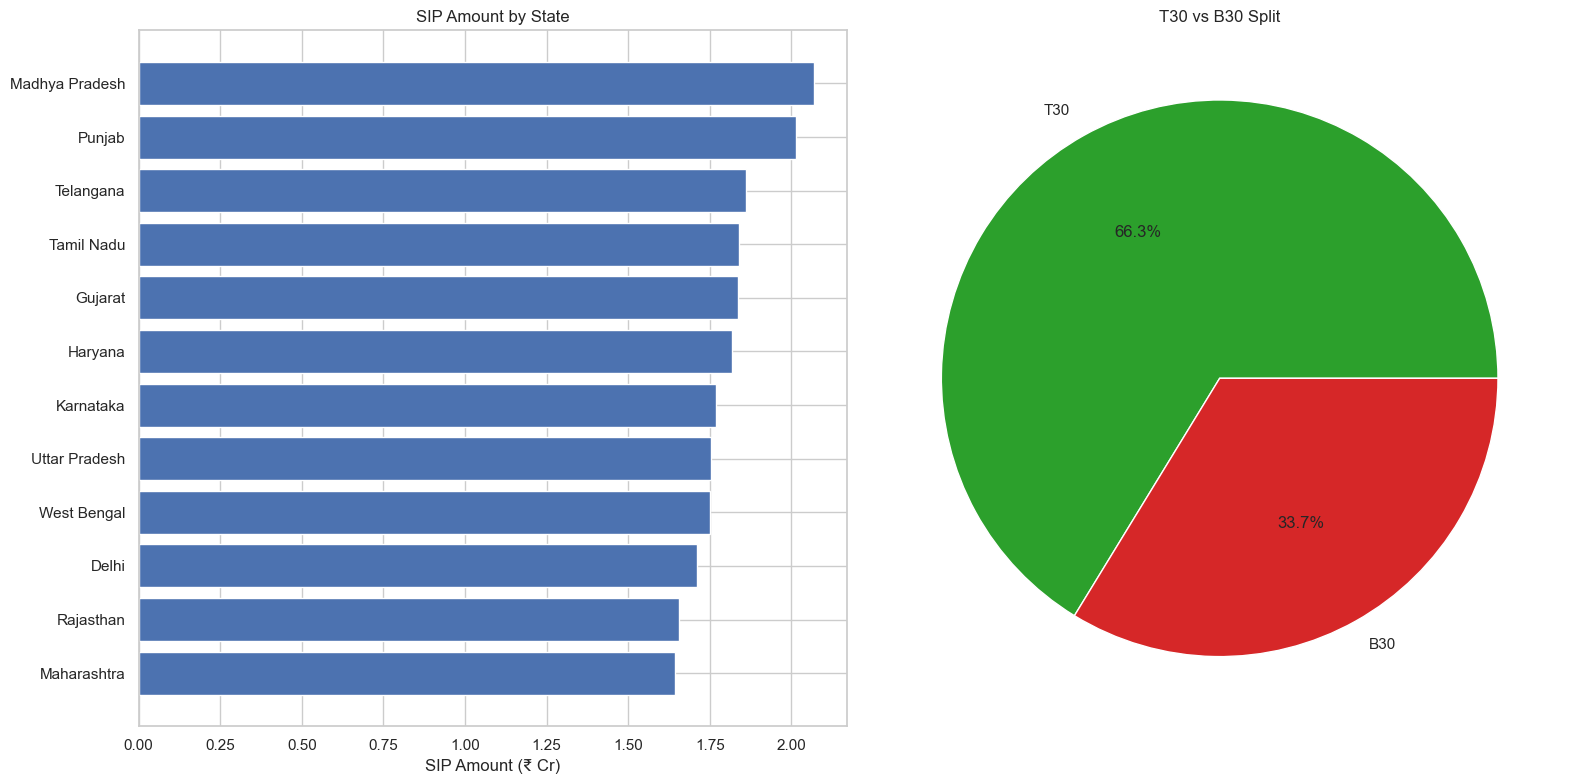

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

state_sip = txn[txn["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().sort_values()
axes[0].barh(state_sip.index, state_sip.values / 1e7)   # convert to ₹ Cr for readability
axes[0].set_xlabel("SIP Amount (₹ Cr)")
axes[0].set_title("SIP Amount by State")

tier_counts = txn["city_tier"].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", colors=["#2ca02c", "#d62728"])
axes[1].set_title("T30 vs B30 Split")

plt.tight_layout()
plt.savefig(CHART_DIR / "06_geographic.png", dpi=150)
plt.show()

Chart 6
=========
- T30 cities account for 66% of SIP volume vs B30's 34%, in line with SEBI's own penetration concerns
- Interestingly, state-level SIP totals are nearly uniform (₹1.64Cr–₹2.07Cr, only a 1.26x spread across 12 states) — unlike the real Indian MF industry, where Maharashtra alone (driven by Mumbai) typically commands a disproportionate share.
- This points to the state field being close to uniformly/randomly generated in this synthetic dataset rather than reflecting real geographic concentration.

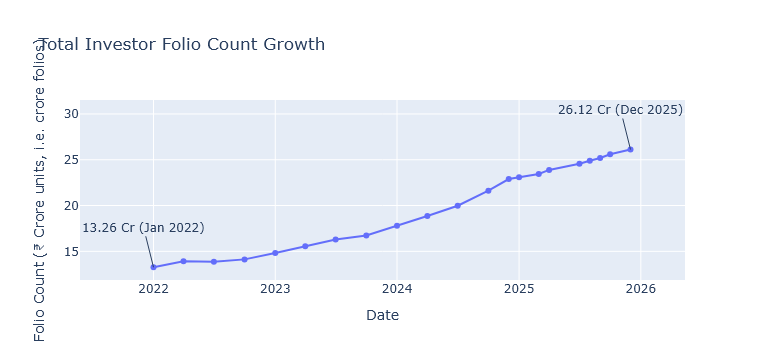

In [23]:
folio["month"] = pd.to_datetime(folio["month"])   # critical — see note below

fig = px.line(folio, x="month", y="total_folios_crore", markers=True,
              title="Total Investor Folio Count Growth")
start = folio.iloc[0]
end = folio.iloc[-1]
fig.add_annotation(x=start["month"].strftime("%Y-%m-%d"), y=start["total_folios_crore"],
                    text=f"{start['total_folios_crore']} Cr ({start['month'].strftime('%b %Y')})", showarrow=True, ay=-40)
fig.add_annotation(x=end["month"].strftime("%Y-%m-%d"), y=end["total_folios_crore"],
                    text=f"{end['total_folios_crore']} Cr ({end['month'].strftime('%b %Y')})", showarrow=True, ay=-40)
fig.update_layout(xaxis_title="Date", yaxis_title="Folio Count (₹ Crore units, i.e. crore folios)")
fig.write_image(CHART_DIR / "07_folio_growth.png")
fig.show()

Chart 7
=========
- Total industry folio count doubled from 13.26 Cr (Jan-2022) to 26.12 Cr 
  (Dec-2025), though the reporting cadence itself shifts from quarterly to 
  irregular near-monthly gaps after Oct-2024, requiring a real datetime axis 
  instead of evenly-spaced categories.

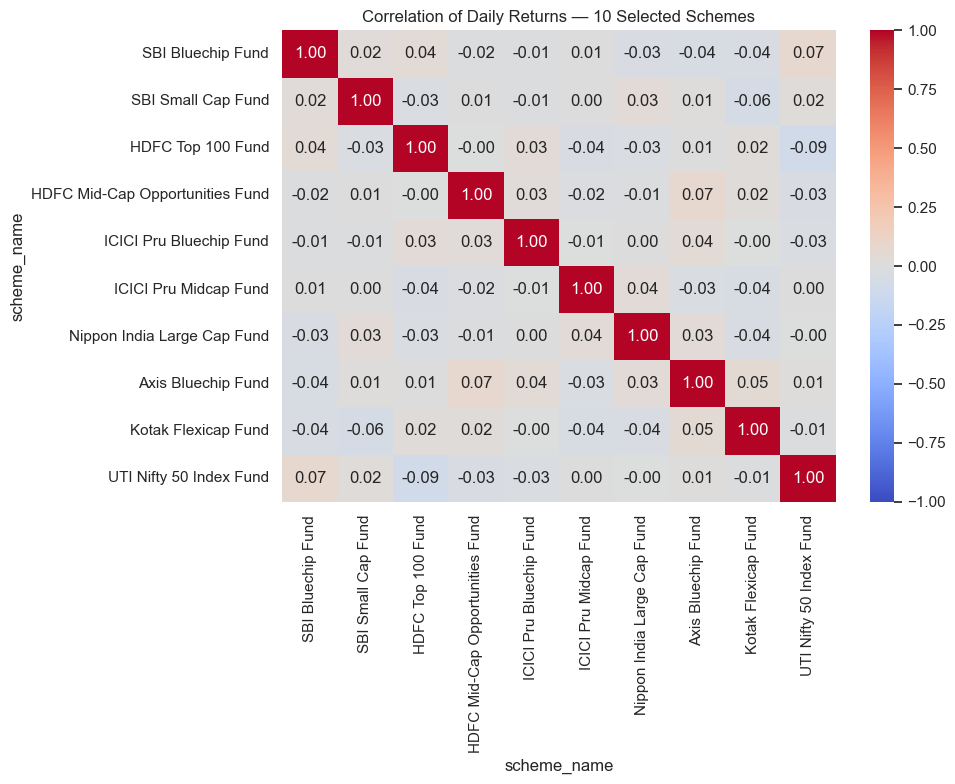

In [24]:
selected = [119551, 119598, 100016, 100033, 120503, 120505, 118632, 119092, 120843, 102885]
# SBI Bluechip, SBI SmallCap, HDFC Top100, HDFC MidCap, ICICI Bluechip,
# ICICI Midcap, Nippon LargeCap, Axis Bluechip, Kotak Flexicap, UTI Nifty50 Index

daily_returns = nav_wide[selected].pct_change()
corr = daily_returns.corr()

names = fund_master.set_index("amfi_code").loc[selected, "scheme_name"].str.replace(" - Regular Plan - Growth", "").str.replace(" - Regular - Growth", "")
corr.index = corr.columns = names

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation of Daily Returns — 10 Selected Schemes")
plt.tight_layout()
plt.savefig(CHART_DIR / "08_correlation_matrix.png", dpi=150)
plt.show()

Chart 8
==========
- Daily-return correlations across 10 distinct schemes are all near-zero 
  (-0.09 to +0.07), atypical for real equity funds (which usually correlate 
  0.7–0.95), suggesting each scheme's NAV was generated as a largely independent 
  process rather than sharing a common market factor.

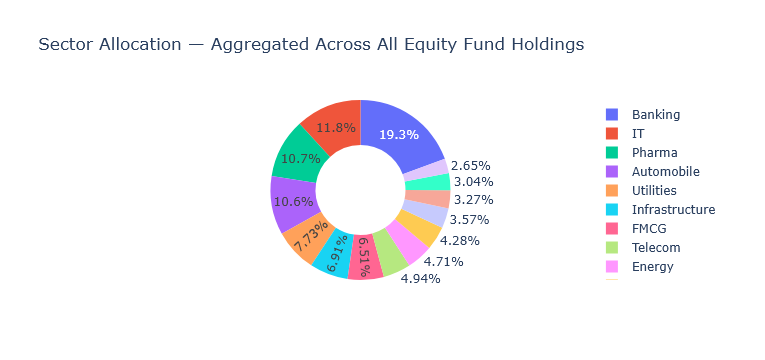

In [25]:
equity_codes = set(fund_master.loc[fund_master["category"] == "Equity", "amfi_code"])
assert set(holdings["amfi_code"].unique()) == equity_codes, "holdings file includes non-equity or is missing some equity schemes"

sector_weights = holdings.groupby("sector")["market_value_cr"].sum().sort_values(ascending=False)
sector_pct = sector_weights / sector_weights.sum() * 100

fig = go.Figure(data=[go.Pie(labels=sector_pct.index, values=sector_pct.values, hole=0.5)])
fig.update_layout(title="Sector Allocation — Aggregated Across All Equity Fund Holdings")
fig.write_image(CHART_DIR / "09_sector_donut.png")
fig.show()

Chart 9
=========
- Banking (19.3%) and IT (11.8%) are the two largest sector exposures aggregated across all 34 equity fund holdings by rupee value — consistent with the large-cap-heavy tilt of the Indian equity fund universe, where banking and IT are the largest listed sectors by market cap.

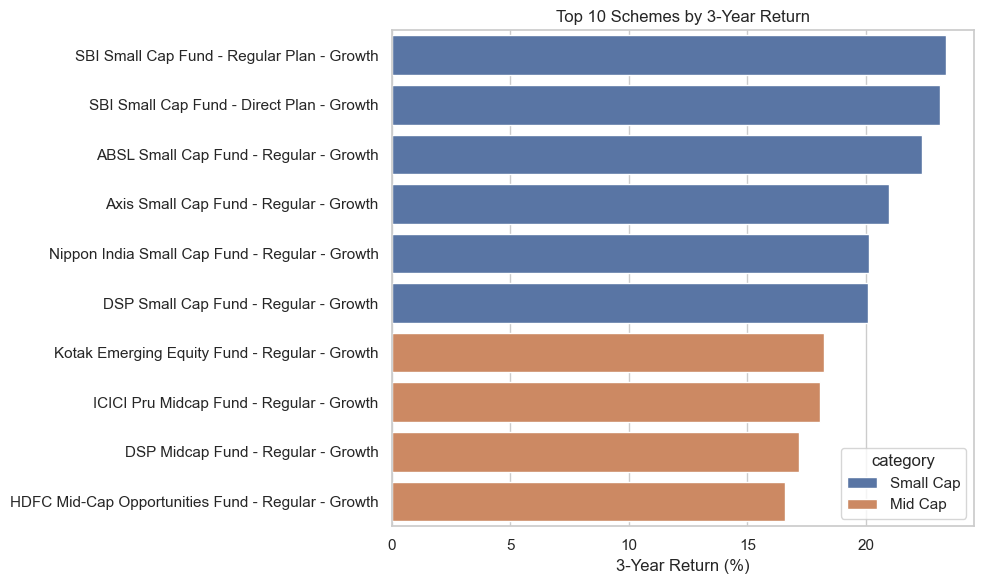

In [26]:
top10 = scheme_perf.sort_values("return_3yr_pct", ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, y="scheme_name", x="return_3yr_pct", hue="category", dodge=False)
plt.title("Top 10 Schemes by 3-Year Return")
plt.xlabel("3-Year Return (%)"); plt.ylabel("")
plt.tight_layout()
plt.savefig(CHART_DIR / "10_top10_returns.png", dpi=150)
plt.show()

Chart 10
==========
- Small/Mid Cap funds dominate the 3-year-return leaderboard (9 of the top 10 schemes), consistent with the real-world pattern that small caps carry higher return alongside higher risk.

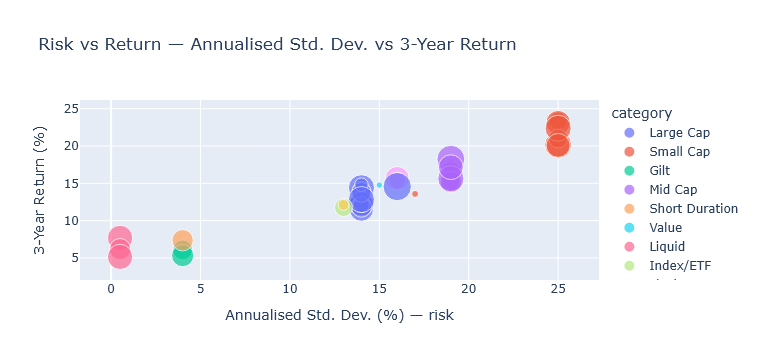

In [27]:
fig = px.scatter(scheme_perf, x="std_dev_ann_pct", y="return_3yr_pct", color="category",
                  size="aum_crore", hover_name="scheme_name",
                  title="Risk vs Return — Annualised Std. Dev. vs 3-Year Return")
fig.update_layout(xaxis_title="Annualised Std. Dev. (%) — risk", yaxis_title="3-Year Return (%)")
fig.write_image(CHART_DIR / "11_risk_return_scatter.png")
fig.show()

Chart 11
==========
- Plotting annualised std. dev. against 3-year return visually confirms the return-for-risk pattern before any Sharpe/Sortino ratio is formally computed — the same relationship these ratios will quantify numerically on Day 4.

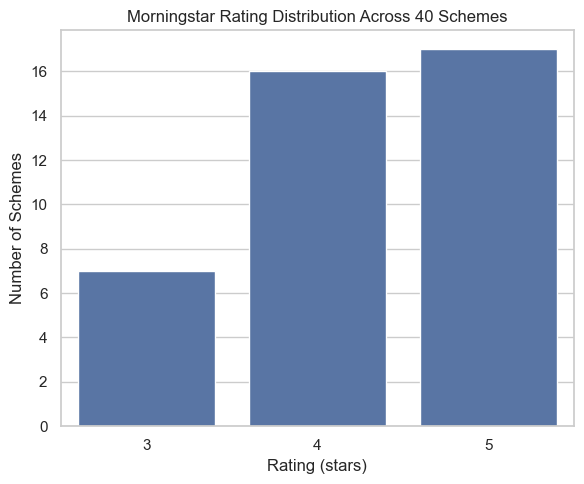

In [28]:
plt.figure(figsize=(6, 5))
sns.countplot(data=scheme_perf, x="morningstar_rating", order=sorted(scheme_perf["morningstar_rating"].unique()))
plt.title("Morningstar Rating Distribution Across 40 Schemes")
plt.xlabel("Rating (stars)"); plt.ylabel("Number of Schemes")
plt.tight_layout()
plt.savefig(CHART_DIR / "12_morningstar_dist.png", dpi=150)
plt.show()

Chart 12
==========
- Ratings only span 3–5 stars in this dataset (7 schemes at 3★, 16 at 4★, 17 at 5★) with zero 1- or 2-star schemes — a synthetic-data skew, since real fund universes typically show a wider spread.

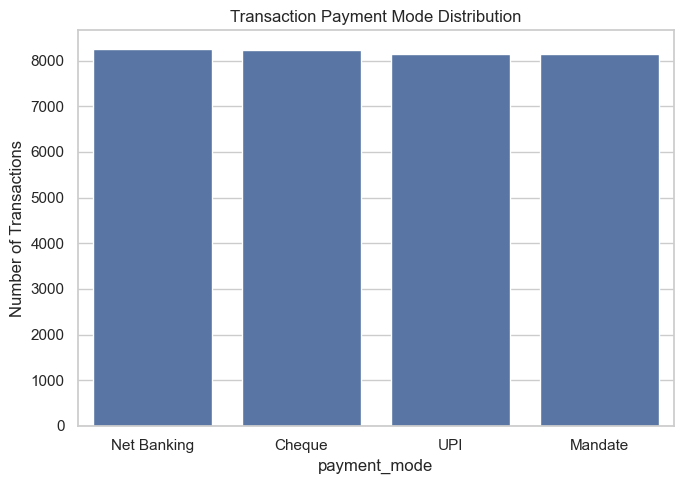

In [29]:
mode_counts = txn["payment_mode"].value_counts()
plt.figure(figsize=(7, 5))
sns.barplot(x=mode_counts.index, y=mode_counts.values)
plt.title("Transaction Payment Mode Distribution")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(CHART_DIR / "13_payment_mode.png", dpi=150)
plt.show()

Chart 13
==========
- Payment mode usage is close to evenly split across Net Banking, Cheque, UPI, and Mandate (all within ~8,150–8,250 transactions), showing no single dominant payment channel among investors in this dataset.